imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import plotting
from pypfopt import expected_returns

load data

In [10]:
tsla = pd.read_csv(
    "../data/processed/TSLA.csv",
    index_col=0,
    parse_dates=True
)

spy = pd.read_csv(
    "../data/processed/SPY.csv",
    index_col=0,
    parse_dates=True
)

bnd = pd.read_csv(
    "../data/processed/BND.csv",
    index_col=0,
    parse_dates=True
)

keep close prices

In [11]:
prices = pd.DataFrame({
    "TSLA": tsla["Close"],
    "SPY": spy["Close"],
    "BND": bnd["Close"]
})

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,205.429993,82.650002
2015-01-05,14.006000,201.720001,82.889999
2015-01-06,14.085333,199.820007,83.129997
2015-01-07,14.063333,202.309998,83.180000
2015-01-08,14.041333,205.899994,83.050003


daily returns

In [12]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002895
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008014,0.001686


calculate historucal return

In [13]:
annual_returns = returns.mean() * 252

annual_returns

TSLA    0.454239
SPY     0.127746
BND    -0.008548
dtype: float64

the value 225.0195 is from task -4 future prediction

In [14]:
forecast_return = (225.0195
    - prices["TSLA"].iloc[-1]
) / prices["TSLA"].iloc[-1]

print(forecast_return)
expected_return = annual_returns.copy()

expected_return["TSLA"] = forecast_return

expected_return

-0.4536239753280673


TSLA   -0.453624
SPY     0.127746
BND    -0.008548
dtype: float64

covariance matrix

In [15]:
cov_matrix = returns.cov() * 252

cov_matrix

,TSLA,SPY,BND
TSLA,0.326926,0.049795,0.001793
SPY,0.049795,0.031402,0.001045
BND,0.001793,0.001045,0.002883


heatmap

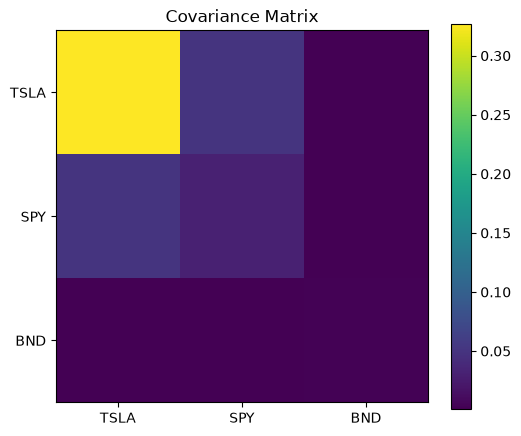

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cov_matrix)

plt.xticks(range(3), cov_matrix.columns)

plt.yticks(range(3), cov_matrix.columns)

plt.colorbar()

plt.title("Covariance Matrix")

plt.show()

create frontier

In [17]:
from pypfopt import EfficientFrontier

ef = EfficientFrontier(expected_return, cov_matrix)

maximum sharpe ratio portfolio

In [18]:
ef = EfficientFrontier(expected_return, cov_matrix)

weights_sharpe = ef.max_sharpe()

cleaned_weights_sharpe = ef.clean_weights()

print(cleaned_weights_sharpe)

OrderedDict({'TSLA': 0.0, 'SPY': 1.0, 'BND': 0.0})


performance of maximum sharpe ratio portfolio

In [19]:
performance_sharpe = ef.portfolio_performance(verbose=True)

Expected annual return: 12.8%
Annual volatility: 17.7%
Sharpe Ratio: 0.72


minimum volatility portfolio

In [20]:
ef_min = EfficientFrontier(expected_return, cov_matrix)

weights_min = ef_min.min_volatility()

cleaned_weights_min = ef_min.clean_weights()

print(cleaned_weights_min)

OrderedDict({'TSLA': 0.0, 'SPY': 0.05709, 'BND': 0.94291})


efficient portfolio plot

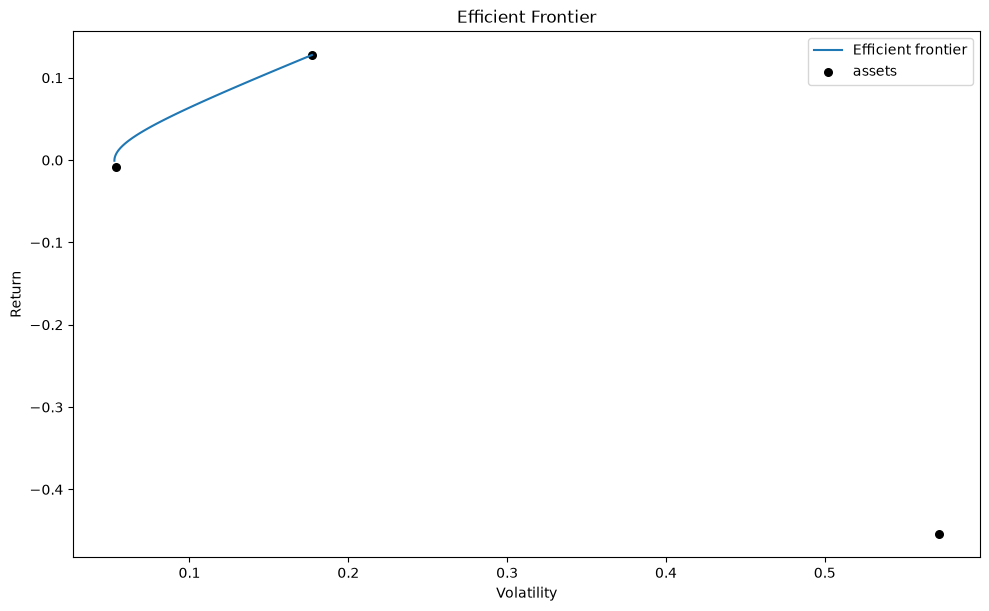

In [21]:
from pypfopt import plotting

ef_plot = EfficientFrontier(expected_return, cov_matrix)

fig, ax = plt.subplots(figsize=(10, 6))

plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

plt.title("Efficient Frontier")

plt.show()

mark the two key portflios

In [22]:
ef = EfficientFrontier(expected_return, cov_matrix)

ef.max_sharpe()

ret_s, vol_s, sharpe_s = ef.portfolio_performance()

ef2 = EfficientFrontier(expected_return, cov_matrix)

ef2.min_volatility()

ret_m, vol_m, sharpe_m = ef2.portfolio_performance()

then plot it

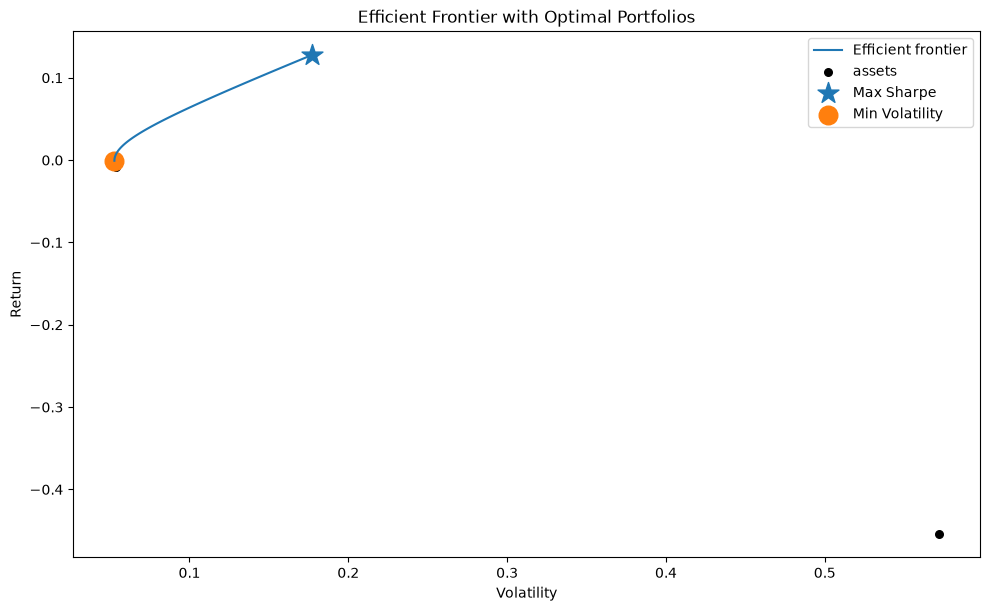

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ef_plot = EfficientFrontier(expected_return, cov_matrix)

plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

ax.scatter(
    vol_s,
    ret_s,
    marker="*",
    s=250,
    label="Max Sharpe"
)

ax.scatter(
    vol_m,
    ret_m,
    marker="o",
    s=180,
    label="Min Volatility"
)

plt.legend()

plt.title("Efficient Frontier with Optimal Portfolios")

plt.show()

final portfolio recommendation

In [24]:
recommendation = pd.DataFrame({
    "Asset": cleaned_weights_sharpe.keys(),
    "Weight": cleaned_weights_sharpe.values()
})

recommendation

,Asset,Weight
0,TSLA,0.0
1,SPY,1.0
2,BND,0.0


portfolio matrix

In [25]:
metrics = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        ret_s,
        vol_s,
        sharpe_s
    ]
})

metrics

,Metric,Value
0,Expected Annual Return,0.127746
1,Annual Volatility,0.177205
2,Sharpe Ratio,0.720892
